In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

In [4]:
# Make sure the file name matches exactly
df = pd.read_csv('store_sales (1) (1).csv')

In [5]:
# Show the first 5 rows
print(df.head())

# Check for data types and missing values
print(df.info())

   CustomerID  Age  Gender       Category ItemPurchased  Amount  Season  \
0           1   58  Female    Accessories       Handbag  115.50  Autumn   
1           2   40    Male  Mens Clothing         Shirt  103.43  Spring   
2           3   66  Female         Sports      Football   35.45  Spring   
3           4   39  Female    Accessories       Handbag  153.31  Spring   
4           5   23  Female           Home      Curtains  151.43  Winter   

  PaymentMethod  ItemRating  DiscountApplied(%)  PreviousPurchases  
0          Card         3.5                  18                  4  
1          Card         4.1                  13                  4  
2          Card         3.3                  11                  3  
3          Card         4.4                  13                  4  
4          Card         4.1                  20                 10  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non

In [7]:
# Selecting numerical features
X = df[['Age', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']]

# The value we want to predict
y = df['Amount']

# Split the data (70% for training, 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [8]:
lm = LinearRegression()
lm.fit(X_train, y_train)

# Print the Intercept and Coefficients
print('Intercept:', lm.intercept_)
print('Coefficients:', lm.coef_)

Intercept: 321.66414446329463
Coefficients: [ 0.14938539 -9.90903086  2.87986008 -9.76513172]


In [9]:
predictions = lm.predict(X_test)

# Calculate Evaluation Metrics
print('MAE (Mean Absolute Error):', metrics.mean_absolute_error(y_test, predictions))
print('MSE (Mean Squared Error):', metrics.mean_squared_error(y_test, predictions))
print('RMSE (Root Mean Squared Error):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE (Mean Absolute Error): 299.1902523379982
MSE (Mean Squared Error): 312065.1363392538
RMSE (Root Mean Squared Error): 558.6279050846402


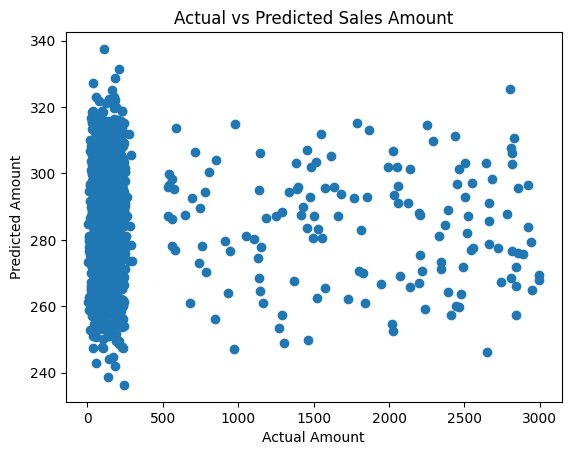

Text(0.5, 1.0, 'Residuals Distribution')

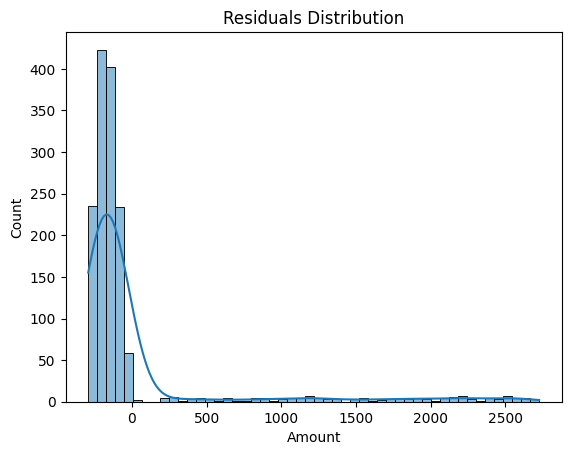

In [10]:
# Scatter plot of Actual vs Predicted
plt.scatter(y_test, predictions)
plt.xlabel('Actual Amount')
plt.ylabel('Predicted Amount')
plt.title('Actual vs Predicted Sales Amount')
plt.show()

# Residual Histogram to check for normal distribution
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title('Residuals Distribution')